## Pixel Shuffling en imagenes de 4 canales

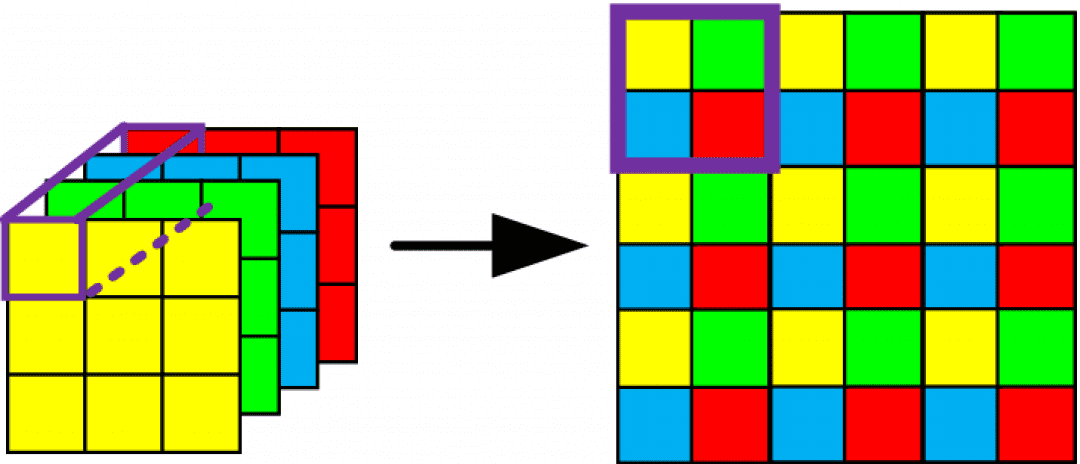

Crear una imagen aleatoria de 4 canales (RGBA)

In [2]:
import numpy as np
from itertools import combinations
import cv2
import os
import matplotlib.pyplot as plt

In [32]:
random_4channel = np.random.randint(0, 256, (3, 3, 4), dtype=np.uint8)
print("Imagen original (3x3x4):")
print(random_4channel)

Imagen original (3x3x4):
[[[ 23  62 252 241]
  [ 65  84 247  79]
  [ 99 145 219 209]]

 [[230  88  26 237]
  [255  71 182 232]
  [ 90 173   4 128]]

 [[110  54  89  52]
  [ 67  36 192 205]
  [ 23  86  43  38]]]


In [41]:
pixel_shuffle_image = np.zeros(shape=(2*random_4channel.shape[0], 2*random_4channel.shape[1]))

for fila in range(pixel_shuffle_image.shape[0]):
    for col in range(pixel_shuffle_image.shape[1]):
        if (fila+1)%2!=0 and (col+1)%2!=0:
            pixel_shuffle_image[fila,col] = 11111
        elif (fila+1)%2==0 and (col+1)%2!=0:
            pixel_shuffle_image[fila,col] = 22222
        elif (fila+1)%2!=0 and (col+1)%2==0:
            pixel_shuffle_image[fila,col] = 33333
        elif (fila+1)%2==0 and (col+1)%2==0:
            pixel_shuffle_image[fila,col] = 44444

print(pixel_shuffle_image)

pixel_shuffle_image[pixel_shuffle_image==11111] = random_4channel[:,:,0].flatten()
pixel_shuffle_image[pixel_shuffle_image==22222] = random_4channel[:,:,1].flatten()
pixel_shuffle_image[pixel_shuffle_image==33333] = random_4channel[:,:,2].flatten()
pixel_shuffle_image[pixel_shuffle_image==44444] = random_4channel[:,:,3].flatten()

print("Imagen después de Pixel Shuffling (6x6):")
print(pixel_shuffle_image)

[[11111. 33333. 11111. 33333. 11111. 33333.]
 [22222. 44444. 22222. 44444. 22222. 44444.]
 [11111. 33333. 11111. 33333. 11111. 33333.]
 [22222. 44444. 22222. 44444. 22222. 44444.]
 [11111. 33333. 11111. 33333. 11111. 33333.]
 [22222. 44444. 22222. 44444. 22222. 44444.]]
Imagen después de Pixel Shuffling (6x6):
[[ 23. 252.  65. 247.  99. 219.]
 [ 62. 241.  84.  79. 145. 209.]
 [230.  26. 255. 182.  90.   4.]
 [ 88. 237.  71. 232. 173. 128.]
 [110.  89.  67. 192.  23.  43.]
 [ 54.  52.  36. 205.  86.  38.]]


In [ ]:
# solucion de gemini
def optimized_pixel_shuffle(random_4channel):
    h, w, c = random_4channel.shape
    shuffled = np.zeros((2 * h, 2 * w))
    
    # 2. Asignamos cada canal a su posición intercalada usando slicing [inicio:fin:paso]
    shuffled[0::2, 0::2] = random_4channel[:, :, 0] # Arriba-Izquierda
    shuffled[1::2, 0::2] = random_4channel[:, :, 1] # Abajo-Izquierda
    shuffled[0::2, 1::2] = random_4channel[:, :, 2] # Arriba-Derecha
    shuffled[1::2, 1::2] = random_4channel[:, :, 3] # Abajo-Derecha
    
    return shuffled

optimized_pixel_shuffle(random_4channel)

array([[ 23., 252.,  65., 247.,  99., 219.],
       [ 62., 241.,  84.,  79., 145., 209.],
       [230.,  26., 255., 182.,  90.,   4.],
       [ 88., 237.,  71., 232., 173., 128.],
       [110.,  89.,  67., 192.,  23.,  43.],
       [ 54.,  52.,  36., 205.,  86.,  38.]])

## Convolución a manito

In [78]:
imagen_grises = np.random.randint(0,255,(10,10), dtype=np.uint8)
kernel = np.ones(shape=(3,3))

# añadir padding a la imagen (0s)
padded_image = np.pad(imagen_grises, pad_width=1, constant_values=0)
print(padded_image)
print(kernel)

[[  0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 132  84 206 141  14 230  86  95 110  72   0]
 [  0 201  88   4 123 111  87 124 141 176  67   0]
 [  0 168 155 175  17 254  62   1 157  54  12   0]
 [  0  90 233  94  97   3 195 221 107 188  90   0]
 [  0  16  96  99 242  59 118 191  66 203  42   0]
 [  0  16 245 178   6 191  31 236 245 200 237   0]
 [  0 233 159 135 107 106 208 174  28 168  32   0]
 [  0 117 241  11 177 211 134  12 116 154  21   0]
 [  0 198  39 142 138  47 148  70  78  54 192   0]
 [  0 168  14  80 192  17 250 220 142  49 113   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0]]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


In [81]:
new_image = np.zeros(imagen_grises.shape, dtype=np.uint64)

for col in range(imagen_grises.shape[1]):
    for fila in range(imagen_grises.shape[0]):
        window = padded_image[fila:fila+len(kernel), col:col+len(kernel)]
        new_image[fila,col] = np.sum(window*kernel)

new_image     

array([[ 505,  715,  646,  599,  706,  652,  763,  732,  661,  425],
       [ 828, 1213,  993, 1045, 1039,  969,  983,  944,  884,  491],
       [ 935, 1208,  986,  878,  949, 1058, 1095, 1169,  992,  587],
       [ 758, 1126, 1208, 1040, 1047, 1104, 1118, 1188,  919,  589],
       [ 696, 1067, 1290,  969,  942, 1245, 1410, 1657, 1378,  960],
       [ 765, 1177, 1267, 1123, 1068, 1314, 1297, 1511, 1221,  882],
       [1011, 1335, 1259, 1122, 1171, 1303, 1184, 1333, 1201,  812],
       [ 987, 1275, 1149, 1074, 1276, 1110,  968,  854,  843,  621],
       [ 777, 1010, 1034, 1015, 1314, 1109, 1170,  895,  919,  583],
       [ 419,  641,  605,  616,  792,  752,  908,  613,  628,  408]],
      dtype=uint64)

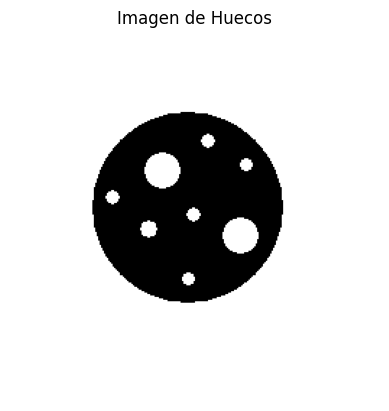

In [23]:
# cargar imagen huecos
huecos_image = cv2.imread('huecos.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(huecos_image, cmap='gray')
plt.title('Imagen de Huecos')
plt.axis('off')
plt.show()

Se desea transformar la imagen binaria Huecos.png como se muestra en siguiente figura, modificando los niveles de gris de la imagen original de la siguiente forma:
- El fondo de la imagen debe quedar negro (nivel de gris = 0).
- El círculo de mayor tamaño debe quedar blanco (nivel de gris = 255).
- Los círculos de tamaño mediano deben quedar negros.
- Los círculos de menor tamaño deben quedar grises (nivel de gris = 0) con su contorno de color negro.

1. seleccionar el fondo de la imagen: rellenar los huecos con apertura

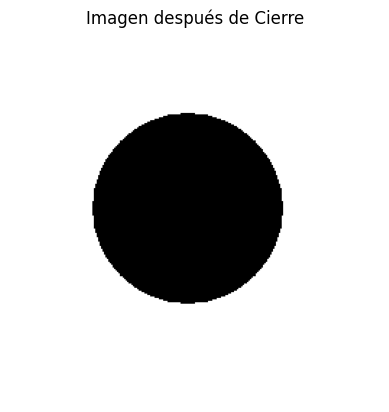

In [33]:
from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle, ball, disk

ball_fp = disk(25)

# aplicar cierre
closed_image = opening(huecos_image, ball_fp)

# visualizar resultado
plt.imshow(closed_image, cmap='gray')
plt.title('Imagen después de Cierre')
plt.axis('off')
plt.show()

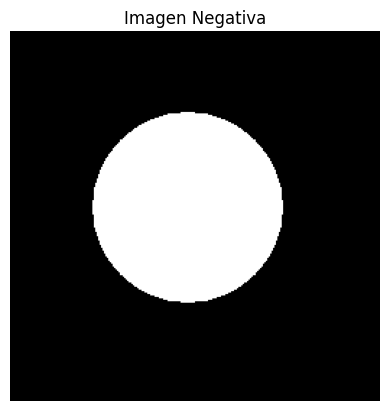

In [34]:
# imagen con el fondo negro y la bola blanca
# negativo
inverse_huecos = 255-closed_image

# visualizar
plt.imshow(inverse_huecos, cmap='gray')
plt.title('Imagen Negativa')
plt.axis('off')
plt.show()

2. tomar los circulos de tamaño mediano y dejarlos en negro - con otra apertura puedo seleccionarlos, y un ee mas pequeño


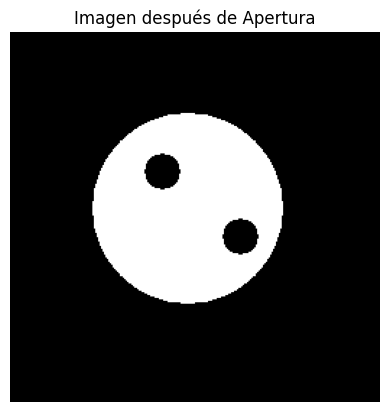

In [73]:
ball_fp = disk(11)

# aplicar apertura
huecos_medianos = opening(huecos_image, ball_fp)

# que queden en negro
huecos_medianos = 255 - huecos_medianos

# visualizar resultado
plt.imshow(huecos_medianos, cmap='gray')
plt.title('Imagen después de Apertura')
plt.axis('off')
plt.show()

4. seleccionar los objetos chiquitos - hacer or de la apertura con el negativo de la original

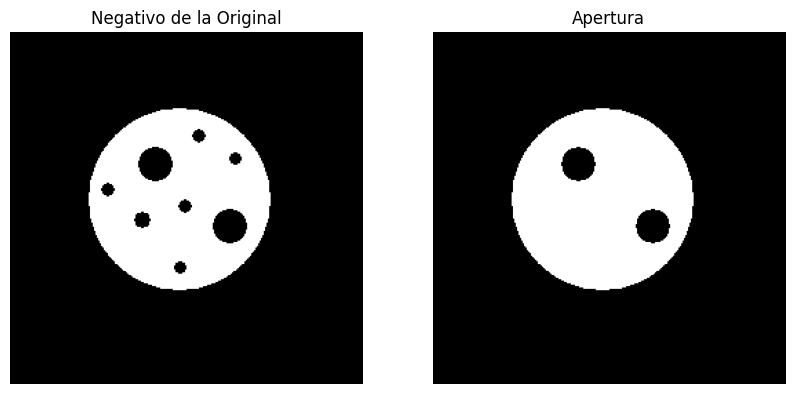

In [74]:
# mirar el negativo de la original y el de la apertura al lado
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(255 - huecos_image, cmap='gray')
plt.title('Negativo de la Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(huecos_medianos, cmap='gray')
plt.title('Apertura')
plt.axis('off')

plt.show()

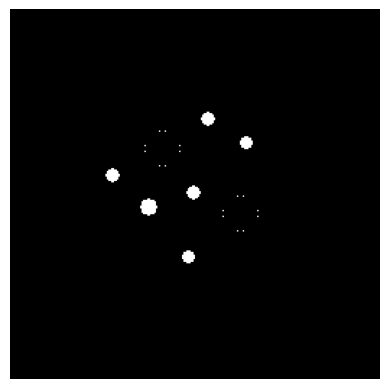

In [75]:
huecos_pequeños = (255-huecos_image)-(huecos_medianos)

# visualizar
plt.imshow(huecos_pequeños, cmap='gray')
plt.axis('off')
plt.show()

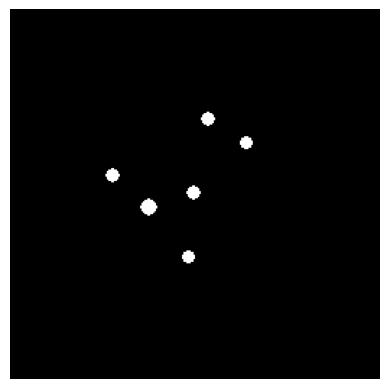

In [76]:
# limpiar detalles chiquitos con un erosion + dilatacion - apertura
ball_fp = disk(3)
huecos_pequeños_limpios = opening(huecos_pequeños, ball_fp)

# visualizar
plt.imshow(huecos_pequeños_limpios, cmap='gray')
plt.axis('off')
plt.show()


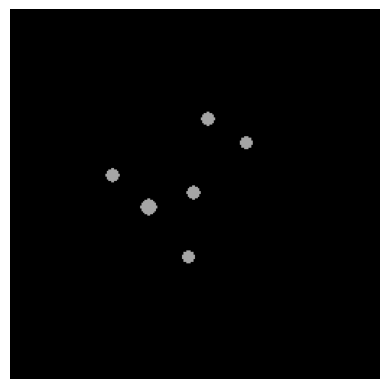

In [77]:
# cambiar el nivel de gris
huecos_pequeños_limpios[huecos_pequeños_limpios==1] = 165

# visualizar
plt.imshow(huecos_pequeños_limpios, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Juntar los huecos pequeños en gris con la imagen de apertura: operacion bitwise_and

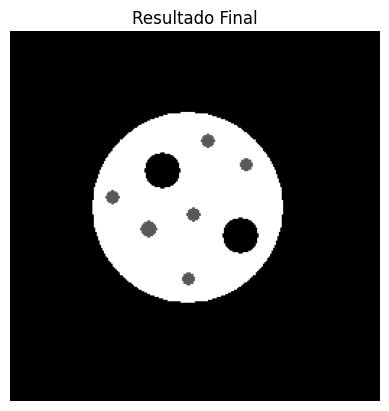

In [78]:
final = cv2.bitwise_xor(huecos_medianos, huecos_pequeños_limpios)

# visualizar resultado final
plt.imshow(final, cmap='gray')
plt.title('Resultado Final')
plt.axis('off')
plt.show()

Me falta el contorno de los chiquitos en negro - aplicar un gradiente morfologico

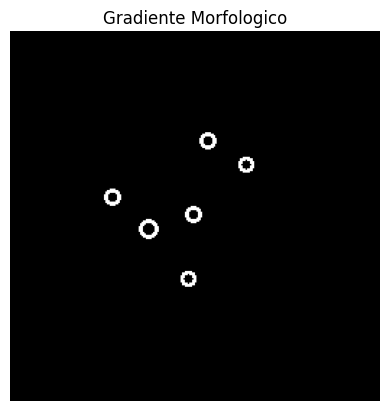

In [79]:
from scipy.ndimage import morphological_gradient

mgimage = morphological_gradient(huecos_pequeños_limpios, size=(3,3))

# visualizar el gradiente morfologico
plt.imshow(mgimage, cmap='gray')
plt.title('Gradiente Morfologico')
plt.axis('off')
plt.show()

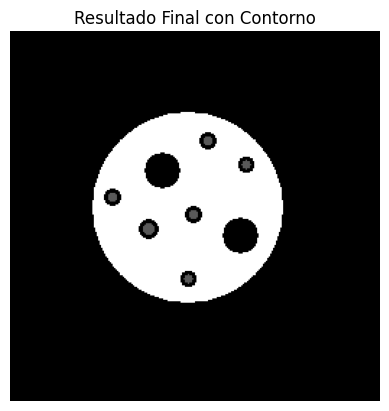

In [80]:
final[mgimage==165] = 0

# visualizar resultado final con contorno
plt.imshow(final, cmap='gray')
plt.title('Resultado Final con Contorno')
plt.axis('off')
plt.show()

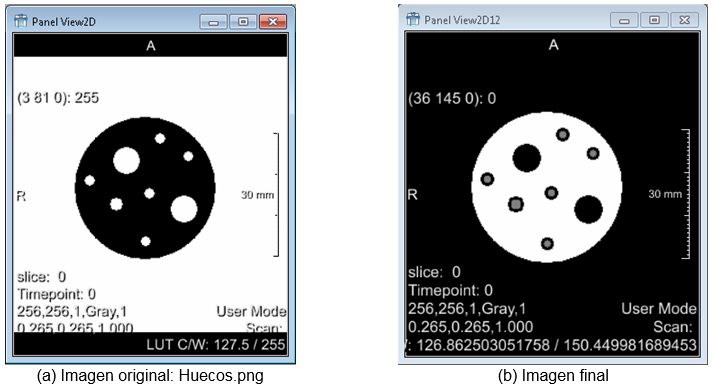